In [1]:
# 1.1 Data Upload
from google.colab import files
uploaded = files.upload()

Saving CIP-01-May-2026_Full Results with Anonymised Learners.xlsx to CIP-01-May-2026_Full Results with Anonymised Learners.xlsx
Saving CIP-01 May 2026 exam correct answers.xlsx to CIP-01 May 2026 exam correct answers.xlsx


In [2]:
# 1.2 Load the answers file and build the lookup table
import pandas as pd
import re

answers_df = pd.read_excel("CIP-01 May 2026 exam correct answers.xlsx")

# This will drop any empty rows
answers_df = answers_df.dropna(subset=["Question Number"])

answers_df = answers_df[["Question Number", "Section from Book", "Chapter", "Correct Response"]].copy()
answers_df["Question Number"] = answers_df["Question Number"].astype(int)

answers_df.head(10)

,Question Number,Section from Book,Chapter,Correct Response
0,1,"Chapter 1, Section C4",1.0,C
4,2,"Chapter 2, Section B3",2.0,D
8,3,"Chapter 2, Section C3b",2.0,D
12,4,"Chapter 3, Section A1",3.0,A
16,5,"Chapter 4, Section B1f",4.0,B
20,6,"Chapter 5, Section E",5.0,B
24,7,"Chapter 6, Section C2",6.0,C
28,8,"Chapter 7, Section A1",7.0,B
32,9,"Chapter 7, Section C4",7.0,D
36,10,"Chapter 8, Section C1c",8.0,C


In [3]:
# 1.3 Extract the learning outcomes
def extract_outcome(category):
    if pd.isna(category):
        return None
    parts = category.split("\\")
    raw = parts[-1].strip('"').strip() if len(parts) > 1 else category
    return re.sub(r'^[KUA]\s*-\s*', '', raw).strip()

raw_answers = pd.read_excel("CIP-01 May 2026 exam correct answers.xlsx")
raw_answers = raw_answers.dropna(subset=["Question Number"])
raw_answers["Question Number"] = raw_answers["Question Number"].astype(int)
raw_answers["Learning Outcome"] = raw_answers["Category"].apply(extract_outcome)

# On first check, this looks good
print(raw_answers["Learning Outcome"].iloc[0])

lookup = raw_answers[["Question Number", "Chapter", "Learning Outcome", "Correct Response"]].copy()
lookup.head()

Explain the structure and operation of the general and private health insurance markets.


,Question Number,Chapter,Learning Outcome,Correct Response
0,1,1.0,Explain the structure and operation of the gen...,C
4,2,2.0,Explain and apply these key insurance terms - ...,D
8,3,2.0,Recognise the interaction between risk managem...,D
12,4,3.0,Explain the role of insurance as a risk transf...,A
16,5,4.0,Demonstrate the relationship between underwrit...,B


In [4]:
# 1.4 Load the results file and reshape it
results_df = pd.read_excel("CIP-01-May-2026_Full Results with Anonymised Learners.xlsx")

records = []

for _, row in results_df.iterrows():
    student_id = row["Student ID"]
    overall_score = row["Overall Score"]
    overall_result = row["Overall Result"]

    for q in range(1, 101):  # 100 questions
        ref_col = f"Q{q} Ref ID"
        ans_col = f"Question{q} Ans"
        score_col = f"Question{q} Score"

        ref_id = row.get(ref_col)
        if pd.isna(ref_id):
            continue


        match = re.search(r'Q(\d+)$', str(ref_id))
        if not match:
            continue
        q_num = int(match.group(1))

        answer = row.get(ans_col)
        score = row.get(score_col)

        records.append({
            "Student ID": student_id,
            "Overall Score": overall_score,
            "Overall Result": overall_result,
            "Question Number": q_num,
            "Answer Given": answer,
            "Raw Score": score
        })

long_df = pd.DataFrame(records)
print(f"Shape: {long_df.shape}")
long_df.head()

Shape: (56100, 6)


,Student ID,Overall Score,Overall Result,Question Number,Answer Given,Raw Score
0,1,-3,Fail,77,A,-1
1,1,-3,Fail,98,E,0
2,1,-3,Fail,13,B,-1
3,1,-3,Fail,7,B,-1
4,1,-3,Fail,15,D,-1


In [5]:
# 1.5 Merge with the answers lookup
merged_df = long_df.merge(lookup, on="Question Number", how="left")

# score of 3 will be correct in this marking scheme of: 3/-1/0
merged_df["Correct"] = (merged_df["Raw Score"] == 3).astype(int)
merged_df["Omitted"] = merged_df["Answer Given"].isin(["NA", "na", None])

print(merged_df.shape)
merged_df.head(10)

(56100, 11)


,Student ID,Overall Score,Overall Result,Question Number,Answer Given,Raw Score,Chapter,Learning Outcome,Correct Response,Correct,Omitted
0,1,-3,Fail,77,A,-1,7.0,Explain the principle of proximate cause and i...,C,0,False
1,1,-3,Fail,98,E,0,8.0,Explain the principle of contribution and appl...,A,0,False
2,1,-3,Fail,13,B,-1,1.0,Explain the structure and operation of the gen...,C,0,False
3,1,-3,Fail,7,B,-1,6.0,"Outline the torts of negligence; trespass, nui...",C,0,False
4,1,-3,Fail,15,D,-1,1.0,Explain the structure and operation of the gen...,B,0,False
5,1,-3,Fail,18,D,-1,1.0,Identify the functions of the main trade and p...,A,0,False
6,1,-3,Fail,95,C,3,8.0,Explain the principle of subrogation and apply...,C,1,False
7,1,-3,Fail,83,C,-1,7.0,Demonstrate the regulatory responsibilities of...,B,0,False
8,1,-3,Fail,53,E,0,5.0,Describe the main elements of a valid contract...,D,0,False
9,1,-3,Fail,64,E,0,5.0,Explain the scope and impact of the legal prin...,C,0,False


In [6]:
# 1.6 Pivot to candidate × question matrix
# This will create a binary correct/incorrect per candidate and per question
pivot_df = merged_df.pivot_table(
    index="Student ID",
    columns="Question Number",
    values="Correct"
).reset_index()

# This will add the overall result back
result_map = results_df.set_index("Student ID")[["Overall Score", "Overall Result"]]
pivot_df = pivot_df.join(result_map, on="Student ID")

print(pivot_df.shape)  # There should be 561 rows × 103 cols (1 ID + 100 Qs + 2 result cols)
pivot_df.head()

(561, 103)


,Student ID,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,100,Overall Score,Overall Result
0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-3,Fail
1,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11,Fail
2,3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13,Fail
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16,Fail
4,5,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,20,Fail


In [7]:
# 1.7 Updated File Save
# Save the long format (useful for EDA and modelling)
merged_df.to_csv("gapfinder_merged_long.csv", index=False)

# Save the wide format (candidate × question matrix)
pivot_df.to_csv("gapfinder_candidate_matrix.csv", index=False)

print("Saved")

Saved


In [8]:
# 2.1 Q-Matrix Completion
import pandas as pd
import re

# Load answers file
raw_answers = pd.read_excel("CIP-01 May 2026 exam correct answers.xlsx")
raw_answers = raw_answers.dropna(subset=["Question Number"])
raw_answers["Question Number"] = raw_answers["Question Number"].astype(int)

# Extract clean learning outcome
def extract_outcome(category):
    if pd.isna(category):
        return None
    parts = category.split("\\")
    raw = parts[-1].strip('"').strip() if len(parts) > 1 else category
    return re.sub(r'^[KUA]\s*-\s*', '', raw).strip()

raw_answers["Learning Outcome"] = raw_answers["Category"].apply(extract_outcome)

raw_answers["value"] = 1

q_matrix = raw_answers.pivot_table(
    index="Question Number",
    columns="Learning Outcome",
    values="value",
    aggfunc="max"
).fillna(0).astype(int)

# This adds chapters for reference
q_matrix.insert(0, "Chapter", raw_answers.set_index("Question Number")["Chapter"])

#For a sanity check, there should be 100 questions x 25 columns (1 chapter + 24 learning outcomes)
print(f"Q-matrix shape: {q_matrix.shape}")
q_matrix.head(10)

Q-matrix shape: (100, 25)


Learning Outcome,Chapter,Classify risks to determine whether they are capable of being insured.,"Define reinsurance, state what prompts its use and outline the main types of reinsurance.",Demonstrate the application of indemnity to a policy of insurance.,Demonstrate the impact of private health insurance principles on the underwriting of this class of insurance.,Demonstrate the regulatory responsibilities of the insurer and the adviser during the claims process.,Demonstrate the relationship between underwriting and the premiums charged for general insurance policies.,Demonstrate the relevant limitation periods applicable in tort.,"Describe the main elements of a valid contract of insurance, how a contract is discharged and remedies for breach of contract.",Describe the typical underwriting measures available to an underwriter when considering a general insurance proposal.,...,"Explain the role of insurance as a risk transfer mechanism, its benefits and how risks are pooled and shared.",Explain the scope and impact of the legal principles of insurable interest and utmost good faith in general insurance and outline how they have been impacted on by the Consumer Insurance Contracts Act 2019.,Explain the structure and operation of the general and private health insurance markets.,Identify the functions of the main trade and professional bodies in the Irish insurance market.,Identify the risks faced by general insurance customers and the appropriate insurance solutions to meet these needs.,Outline the concept of indemnity and identify an insurer's settlement options when providing indemnity to a policyholder.,Outline the role of the professionals involved in the general insurance underwriting process.,Outline the structure of a general insurance policy and explain the impact of a breach of policy condition.,"Outline the torts of negligence; trespass, nuisance, strict liability, defamation and breach of statutory duty as they apply to insurance.",Recognise the interaction between risk management and insurance and identify the risk management techniques that can protect customers and their businesses (physically and financially).
Question Number,,,,,,,,,,,,,,,,,,,,,
1,1.0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3.0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,4.0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,5.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7,6.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,7.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,7.0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# 2.2 Q-Matrix Saving
q_matrix.to_csv("gapfinder_qmatrix.csv")
print("Q-matrix saved.")

Q-matrix saved.


In [10]:
# 2.3 Checking Rows For Outcomes Noted
# This is to see which questions map to which outcomes marked by a 1
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

q_matrix

Learning Outcome,Chapter,Classify risks to determine whether they are capable of being insured.,"Define reinsurance, state what prompts its use and outline the main types of reinsurance.",Demonstrate the application of indemnity to a policy of insurance.,Demonstrate the impact of private health insurance principles on the underwriting of this class of insurance.,Demonstrate the regulatory responsibilities of the insurer and the adviser during the claims process.,Demonstrate the relationship between underwriting and the premiums charged for general insurance policies.,Demonstrate the relevant limitation periods applicable in tort.,"Describe the main elements of a valid contract of insurance, how a contract is discharged and remedies for breach of contract.",Describe the typical underwriting measures available to an underwriter when considering a general insurance proposal.,"Explain and apply these key insurance terms - risk, uncertainty, frequency, severity, peril and hazard.",Explain the principle of contribution and apply it in situations where dual insurance exists.,Explain the principle of proximate cause and illustrate its operation in the claims process.,Explain the principle of subrogation and apply it in situations where recovery rights may be exercised.,Explain the responsibilities of the insured after a loss.,"Explain the role of insurance as a risk transfer mechanism, its benefits and how risks are pooled and shared.",Explain the scope and impact of the legal principles of insurable interest and utmost good faith in general insurance and outline how they have been impacted on by the Consumer Insurance Contracts Act 2019.,Explain the structure and operation of the general and private health insurance markets.,Identify the functions of the main trade and professional bodies in the Irish insurance market.,Identify the risks faced by general insurance customers and the appropriate insurance solutions to meet these needs.,Outline the concept of indemnity and identify an insurer's settlement options when providing indemnity to a policyholder.,Outline the role of the professionals involved in the general insurance underwriting process.,Outline the structure of a general insurance policy and explain the impact of a breach of policy condition.,"Outline the torts of negligence; trespass, nuisance, strict liability, defamation and breach of statutory duty as they apply to insurance.",Recognise the interaction between risk management and insurance and identify the risk management techniques that can protect customers and their businesses (physically and financially).
Question Number,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
5,4.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,5.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
7,6.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
8,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9,7.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
# 3.1 Load Saved Files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

merged_df = pd.read_csv("gapfinder_merged_long.csv")
q_matrix = pd.read_csv("gapfinder_qmatrix.csv", index_col="Question Number")


print("Q-matrix shape:", q_matrix.shape)
merged_df.head()

Q-matrix shape: (100, 25)


,Student ID,Overall Score,Overall Result,Question Number,Answer Given,Raw Score,Chapter,Learning Outcome,Correct Response,Correct,Omitted
0,1,-3,Fail,77,A,-1,7.0,Explain the principle of proximate cause and i...,C,0,False
1,1,-3,Fail,98,E,0,8.0,Explain the principle of contribution and appl...,A,0,False
2,1,-3,Fail,13,B,-1,1.0,Explain the structure and operation of the gen...,C,0,False
3,1,-3,Fail,7,B,-1,6.0,"Outline the torts of negligence; trespass, nui...",C,0,False
4,1,-3,Fail,15,D,-1,1.0,Explain the structure and operation of the gen...,B,0,False


n = 561
Overall Result
Pass    410
Fail    151
Name: count, dtype: int64
count    561.0
mean     166.1
std       69.7
min       -3.0
25%      112.0
50%      171.0
75%      221.0
max      300.0
Name: Overall Score, dtype: float64


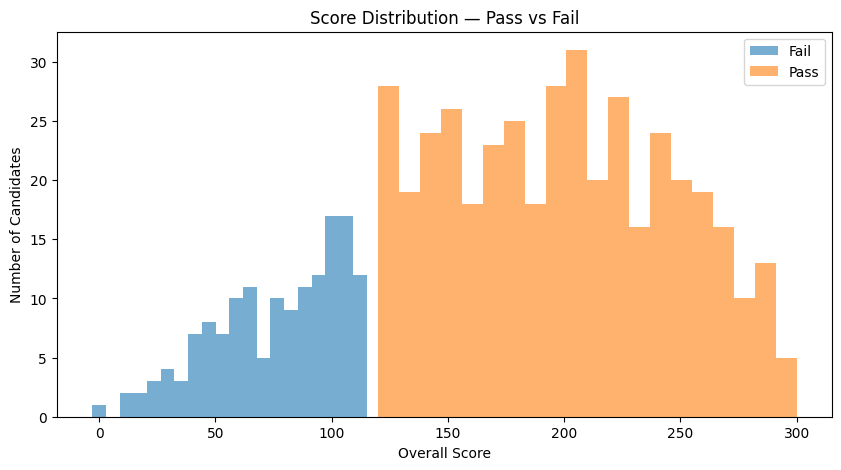

In [12]:
# 3.2 Overall pass/fail summary

total = len(merged_df["Student ID"].unique())
passes = merged_df.drop_duplicates("Student ID")["Overall Result"].value_counts()
scores = merged_df.drop_duplicates("Student ID")["Overall Score"]

print(f"n = {total}")
print(passes)
print(scores.describe().round(1))

# Score distribution by result
fig, ax = plt.subplots(figsize=(10, 5))
for result, group in merged_df.drop_duplicates("Student ID").groupby("Overall Result"):
    ax.hist(group["Overall Score"], bins=20, alpha=0.6, label=result)
ax.set_xlabel("Overall Score")
ax.set_ylabel("Number of Candidates")
ax.set_title("Score Distribution — Pass vs Fail")
ax.legend()
plt.savefig("eda_score_distribution.png", dpi=150)
plt.show()


Response Type
Correct    34402
Omitted    11700
Wrong       9998
Name: count, dtype: int64

As %:
Response Type
Correct    61.3
Omitted    20.9
Wrong      17.8
Name: count, dtype: float64
Response Type
Correct    34402
Omitted    11700
Wrong       9998
Name: count, dtype: int64

As %:
Response Type
Correct    61.3
Omitted    20.9
Wrong      17.8
Name: count, dtype: float64


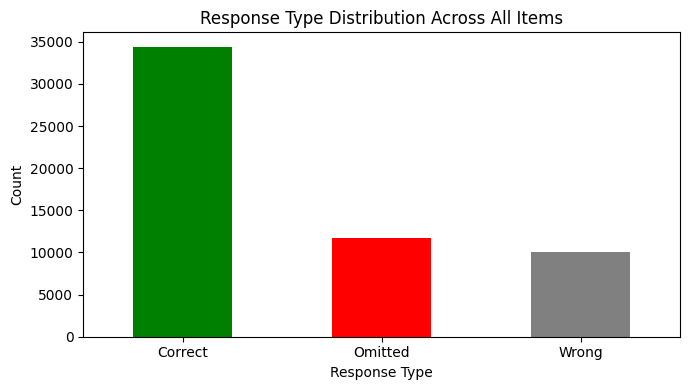

In [13]:
# 3.3 Correct / Wrong / Omitted breakdown
# This fixes type before applying response_type
merged_df["Raw Score"] = pd.to_numeric(merged_df["Raw Score"], errors="coerce")

def response_type(row):
    if row["Raw Score"] == 3:
        return "Correct"
    elif str(row["Answer Given"]).upper() in ["NA", "NAN"] or row["Raw Score"] == 0:
        return "Omitted"
    else:
        return "Wrong"

merged_df["Response Type"] = merged_df.apply(response_type, axis=1)

totals = merged_df["Response Type"].value_counts()
print(totals)
print(f"\nAs %:\n{(totals / totals.sum() * 100).round(1)}")
# This encodes response type
def response_type(row):
    if row["Raw Score"] == 3:
        return "Correct"
    elif str(row["Answer Given"]).upper() in ["NA", "NAN"] or row["Raw Score"] == 0:
        return "Omitted"
    else:
        return "Wrong"

merged_df["Response Type"] = merged_df.apply(response_type, axis=1)

totals = merged_df["Response Type"].value_counts()
print(totals)
print(f"\nAs %:\n{(totals / totals.sum() * 100).round(1)}")

totals.plot(kind="bar", color=["green", "red", "grey"], figsize=(7, 4))
plt.title("Response Type Distribution Across All Items")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_response_types.png", dpi=150)
plt.show()

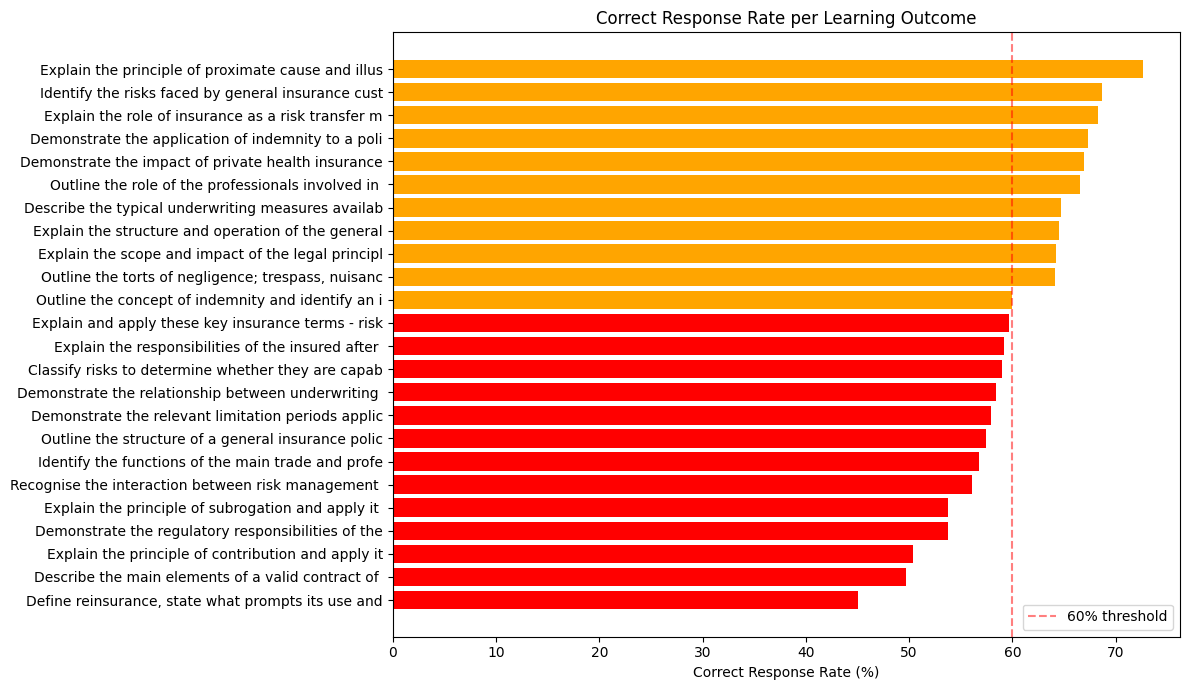

                                       Short Label  Pass Rate (%)
Define reinsurance, state what prompts its use and           45.1
Describe the main elements of a valid contract of            49.7
Explain the principle of contribution and apply it           50.4
Demonstrate the regulatory responsibilities of the           53.8
Explain the principle of subrogation and apply it            53.8
Recognise the interaction between risk management            56.1
Identify the functions of the main trade and profe           56.8
Outline the structure of a general insurance polic           57.4
Demonstrate the relevant limitation periods applic           57.9
Demonstrate the relationship between underwriting            58.4
Classify risks to determine whether they are capab           59.0
Explain the responsibilities of the insured after            59.2
Explain and apply these key insurance terms - risk           59.7
Outline the concept of indemnity and identify an i           60.0
Outline th

In [14]:
# 3.4 Pass rate per learning outcome
outcome_stats = merged_df.groupby("Learning Outcome").agg(
    Total_Responses=("Correct", "count"),
    Correct_Responses=("Correct", "sum")
).reset_index()

outcome_stats["Pass Rate (%)"] = (
    outcome_stats["Correct_Responses"] / outcome_stats["Total_Responses"] * 100
).round(1)

outcome_stats = outcome_stats.sort_values("Pass Rate (%)")

# This makes the label shorter for display purposes
outcome_stats["Short Label"] = outcome_stats["Learning Outcome"].str[:50]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(outcome_stats["Short Label"], outcome_stats["Pass Rate (%)"],
               color=["red" if x < 60 else "orange" if x < 75 else "green"
                      for x in outcome_stats["Pass Rate (%)"]])
ax.axvline(x=60, color="red", linestyle="--", alpha=0.5, label="60% threshold")
ax.set_xlabel("Correct Response Rate (%)")
ax.set_title("Correct Response Rate per Learning Outcome")
ax.legend()
plt.tight_layout()
plt.savefig("eda_outcome_passrates.png", dpi=150)
plt.show()

print(outcome_stats[["Short Label", "Pass Rate (%)"]].to_string(index=False))

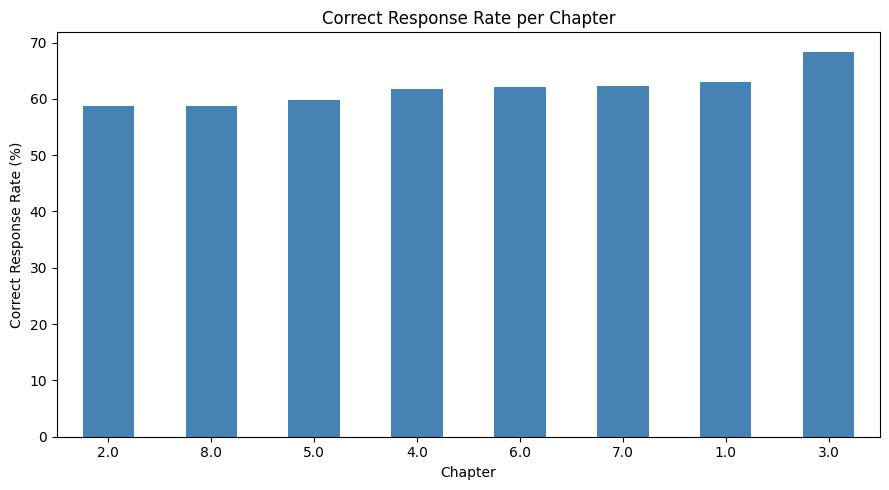

 Chapter  Total  Correct  Pass Rate (%)
     2.0   7293     4278           58.7
     8.0   8976     5275           58.8
     5.0   8976     5364           59.8
     4.0   8415     5204           61.8
     6.0   5049     3133           62.1
     7.0   7293     4543           62.3
     1.0   5610     3533           63.0
     3.0   4488     3072           68.4


In [15]:
# 3.5 Pass rate per learning outcome
chapter_stats = merged_df.groupby("Chapter").agg(
    Total=("Correct", "count"),
    Correct=("Correct", "sum")
).reset_index()
chapter_stats["Pass Rate (%)"] = (chapter_stats["Correct"] / chapter_stats["Total"] * 100).round(1)
chapter_stats = chapter_stats.sort_values("Pass Rate (%)")

chapter_stats.plot(kind="bar", x="Chapter", y="Pass Rate (%)",
                   figsize=(9, 5), legend=False, color="steelblue")
plt.title("Correct Response Rate per Chapter")
plt.ylabel("Correct Response Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_chapter_passrates.png", dpi=150)
plt.show()

print(chapter_stats.to_string(index=False))

Flagged questions (too easy or too hard): 4
 Question Number  Correct_Rate_%
              58            22.6
              69            38.3
              71            94.5
              97            39.4


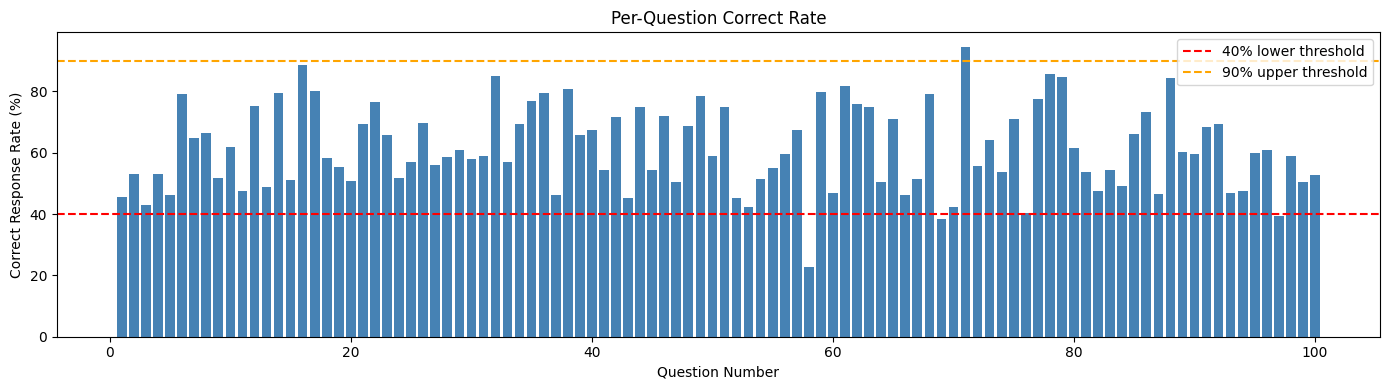

In [16]:
# 3.6 Per-question correct rate (flag low-variance items)
q_stats = merged_df.groupby("Question Number").agg(
    Correct_Rate=("Correct", "mean"),
    Total=("Correct", "count")
).reset_index()
q_stats["Correct_Rate_%"] = (q_stats["Correct_Rate"] * 100).round(1)

# This will flag anything below 40% or above 90% which is not useful diagnositcally
low_variance = q_stats[(q_stats["Correct_Rate_%"] < 40) | (q_stats["Correct_Rate_%"] > 90)]
print(f"Flagged questions (too easy or too hard): {len(low_variance)}")
print(low_variance[["Question Number", "Correct_Rate_%"]].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(q_stats["Question Number"], q_stats["Correct_Rate_%"], color="steelblue")
ax.axhline(y=40, color="red", linestyle="--", label="40% lower threshold")
ax.axhline(y=90, color="orange", linestyle="--", label="90% upper threshold")
ax.set_xlabel("Question Number")
ax.set_ylabel("Correct Response Rate (%)")
ax.set_title("Per-Question Correct Rate")
ax.legend()
plt.tight_layout()
plt.savefig("eda_per_question_rates.png", dpi=150)
plt.show()

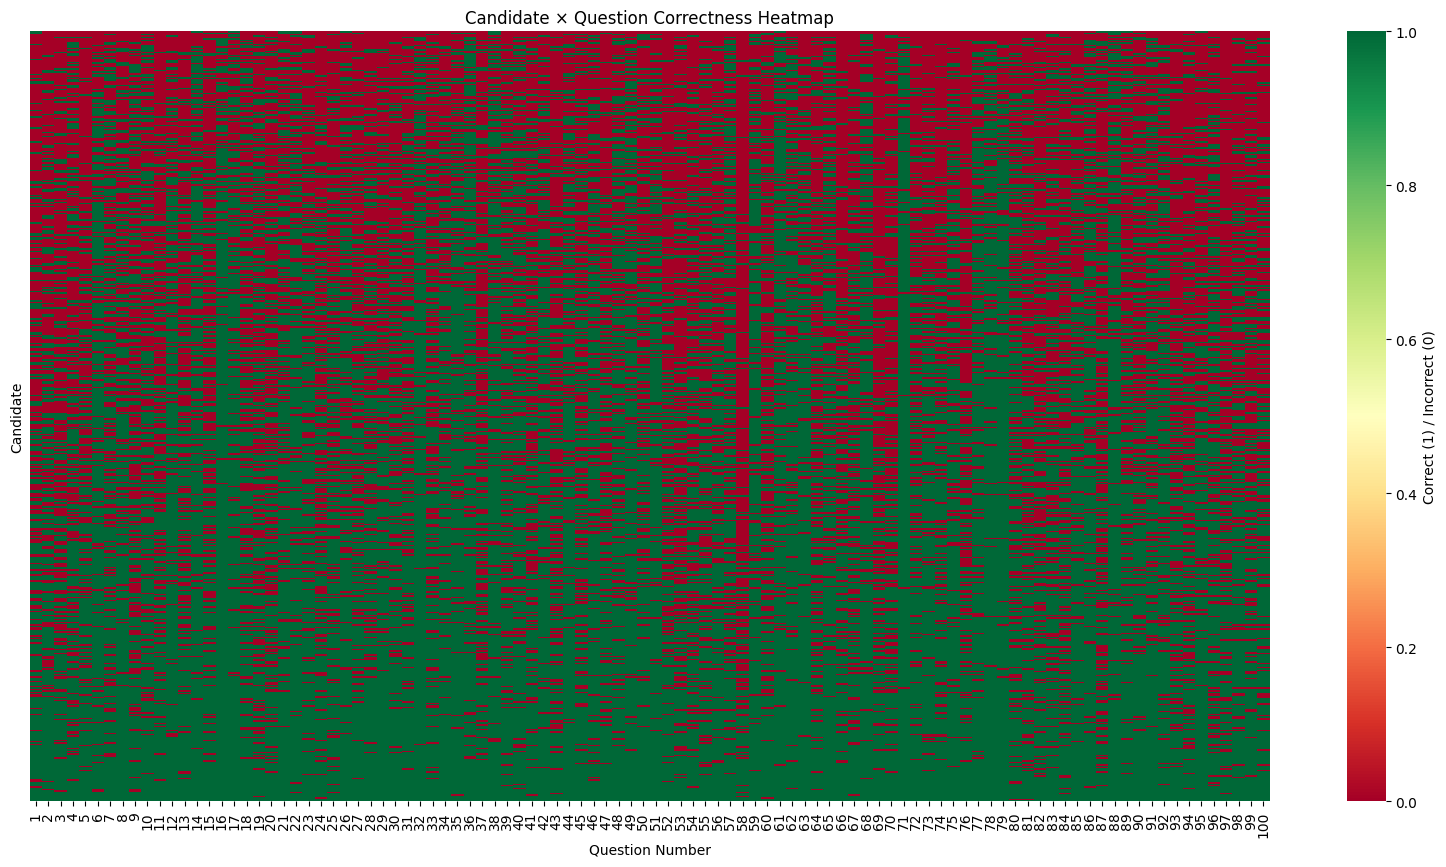

In [17]:
# 3.7 Correctness heatmap (candidates × questions)
heatmap_df = merged_df.pivot_table(
    index="Student ID",
    columns="Question Number",
    values="Correct"
)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(heatmap_df, cmap="RdYlGn", linewidths=0,
            xticklabels=True, yticklabels=False,
            cbar_kws={"label": "Correct (1) / Incorrect (0)"}, ax=ax)
ax.set_title("Candidate × Question Correctness Heatmap")
ax.set_xlabel("Question Number")
ax.set_ylabel("Candidate")
plt.savefig("eda_heatmap.png", dpi=150)
plt.show()

In [18]:
# 3.8 Save EDA summary table
# Full summary per question with chapter and outcome
q_full = merged_df.groupby(["Question Number", "Chapter", "Learning Outcome"]).agg(
    Correct_Rate=("Correct", "mean"),
    Wrong_Rate=(  "Response Type", lambda x: (x == "Wrong").mean()),
    Omit_Rate=(   "Response Type", lambda x: (x == "Omitted").mean()),
    N=("Correct", "count")
).reset_index()

q_full["Correct_%"] = (q_full["Correct_Rate"] * 100).round(1)
q_full["Wrong_%"]   = (q_full["Wrong_Rate"]   * 100).round(1)
q_full["Omit_%"]    = (q_full["Omit_Rate"]    * 100).round(1)

q_full.drop(columns=["Correct_Rate","Wrong_Rate","Omit_Rate"]).to_csv(
    "eda_question_summary.csv", index=False)
print("Done")
q_full.head(10)

Done


,Question Number,Chapter,Learning Outcome,Correct_Rate,Wrong_Rate,Omit_Rate,N,Correct_%,Wrong_%,Omit_%
0,1,1.0,Explain the structure and operation of the gen...,0.456328,0.144385,0.399287,561,45.6,14.4,39.9
1,2,2.0,Explain and apply these key insurance terms - ...,0.529412,0.146168,0.324421,561,52.9,14.6,32.4
2,3,2.0,Recognise the interaction between risk managem...,0.427807,0.222816,0.349376,561,42.8,22.3,34.9
3,4,3.0,Explain the role of insurance as a risk transf...,0.529412,0.208556,0.262032,561,52.9,20.9,26.2
4,5,4.0,Demonstrate the relationship between underwrit...,0.463458,0.067736,0.468806,561,46.3,6.8,46.9
5,6,5.0,Explain the scope and impact of the legal prin...,0.791444,0.114082,0.094474,561,79.1,11.4,9.4
6,7,6.0,"Outline the torts of negligence; trespass, nui...",0.647059,0.294118,0.058824,561,64.7,29.4,5.9
7,8,7.0,Explain the responsibilities of the insured af...,0.664884,0.121212,0.213904,561,66.5,12.1,21.4
8,9,7.0,Demonstrate the regulatory responsibilities of...,0.516934,0.126560,0.356506,561,51.7,12.7,35.7
9,10,8.0,Demonstrate the application of indemnity to a ...,0.620321,0.185383,0.194296,561,62.0,18.5,19.4


In [19]:
# 4.1 Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

merged_df = pd.read_csv("gapfinder_merged_long.csv")
merged_df["Raw Score"] = pd.to_numeric(merged_df["Raw Score"], errors="coerce")

# TO-DO: It might be worth checking out if any Raw Score values are unexpected
def response_type(row):
    if row["Raw Score"] == 3:
        return "Correct"
    elif str(row["Answer Given"]).upper() in ["NA", "NAN"] or row["Raw Score"] == 0:
        return "Omitted"
    else:
        return "Wrong"

merged_df["Response Type"] = merged_df.apply(response_type, axis=1)

print("Loaded:", merged_df.shape)
merged_df.head()

Loaded: (56100, 12)


,Student ID,Overall Score,Overall Result,Question Number,Answer Given,Raw Score,Chapter,Learning Outcome,Correct Response,Correct,Omitted,Response Type
0,1,-3,Fail,77,A,-1.0,7.0,Explain the principle of proximate cause and i...,C,0,False,Wrong
1,1,-3,Fail,98,E,0.0,8.0,Explain the principle of contribution and appl...,A,0,False,Omitted
2,1,-3,Fail,13,B,-1.0,1.0,Explain the structure and operation of the gen...,C,0,False,Wrong
3,1,-3,Fail,7,B,-1.0,6.0,"Outline the torts of negligence; trespass, nui...",C,0,False,Wrong
4,1,-3,Fail,15,D,-1.0,1.0,Explain the structure and operation of the gen...,B,0,False,Wrong


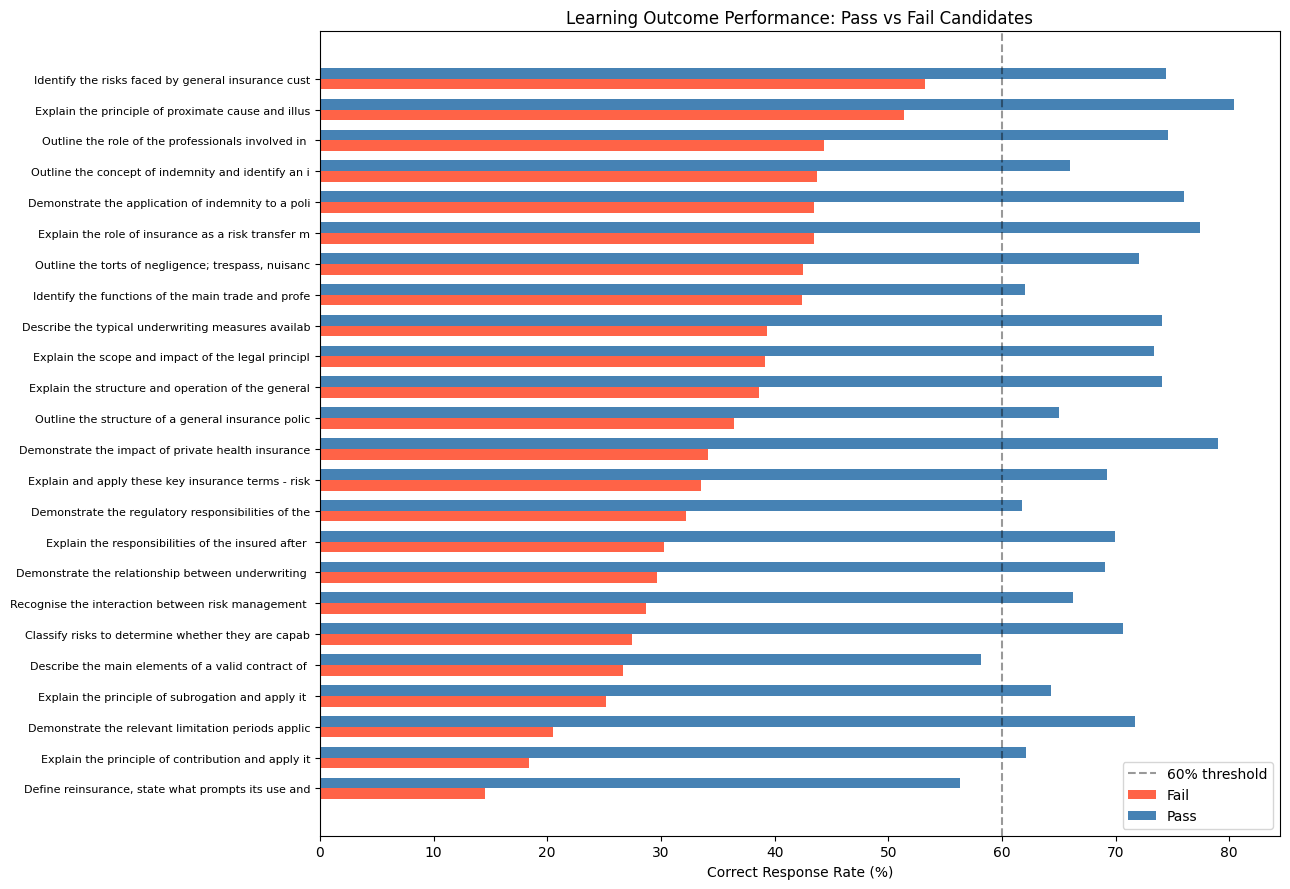


Gap between pass and fail candidates per outcome:
                                                         Fail       Pass  Gap (Pass - Fail)
Learning Outcome                                                                           
Demonstrate the relevant limitation periods applic  20.529801  71.707317               51.2
Demonstrate the impact of private health insurance  34.105960  79.024390               44.9
Explain the principle of contribution and apply it  18.377483  62.134146               43.8
Classify risks to determine whether they are capab  27.483444  70.670732               43.2
Define reinsurance, state what prompts its use and  14.569536  56.341463               41.8
Explain the responsibilities of the insured after   30.242826  69.918699               39.7
Demonstrate the relationship between underwriting   29.668874  69.024390               39.4
Explain the principle of subrogation and apply it   25.165563  64.329268               39.2
Recognise the interaction bet

In [20]:
# 4.2 Learning outcome performance: pass vs fail split

outcome_by_result = merged_df.groupby(
    ["Learning Outcome", "Overall Result"]
)["Correct"].mean().unstack() * 100

outcome_by_result.columns = ["Fail", "Pass"]
outcome_by_result["Gap (Pass - Fail)"] = (
    outcome_by_result["Pass"] - outcome_by_result["Fail"]
).round(1)
outcome_by_result = outcome_by_result.sort_values("Fail")

# Shorten labels
outcome_by_result.index = outcome_by_result.index.str[:50]

fig, ax = plt.subplots(figsize=(13, 9))
x = np.arange(len(outcome_by_result))
width = 0.35

ax.barh(x - width/2, outcome_by_result["Fail"], width,
        label="Fail", color="tomato")
ax.barh(x + width/2, outcome_by_result["Pass"], width,
        label="Pass", color="steelblue")

ax.set_yticks(x)
ax.set_yticklabels(outcome_by_result.index, fontsize=8)
ax.set_xlabel("Correct Response Rate (%)")
ax.set_title("Learning Outcome Performance: Pass vs Fail Candidates")
ax.axvline(x=60, color="black", linestyle="--", alpha=0.4, label="60% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("eda2_outcome_pass_vs_fail.png", dpi=150)
plt.show()

print("\nGap between pass and fail candidates per outcome:")
print(outcome_by_result.sort_values("Gap (Pass - Fail)", ascending=False).to_string())

/tmp/ipykernel_13303/847466947.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: (x["Response Type"] == "Omitted").mean() * 100).unstack()


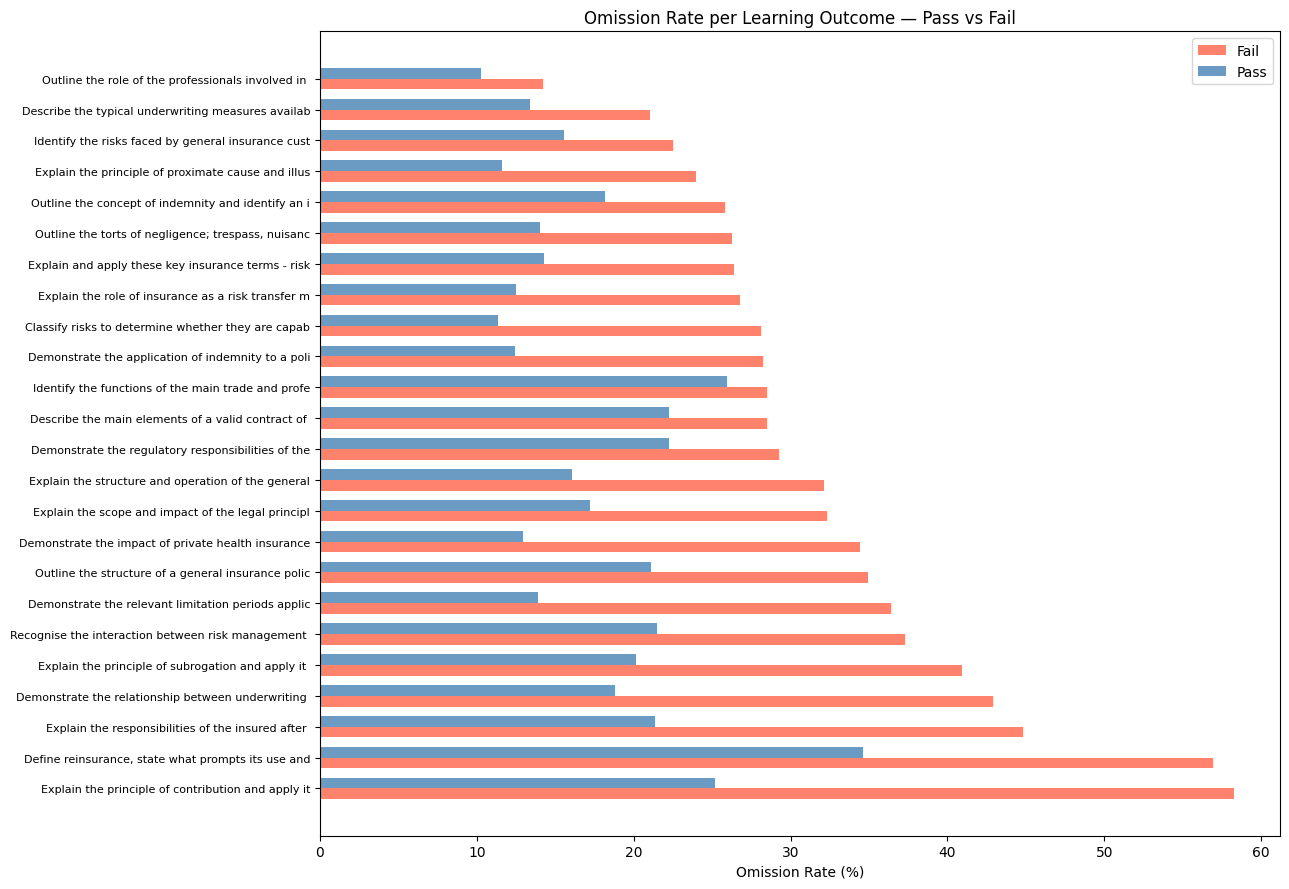

                                                    Fail_Omit%  Pass_Omit%
Learning Outcome                                                          
Explain the principle of contribution and apply it   58.278146   25.182927
Define reinsurance, state what prompts its use and   56.953642   34.634146
Explain the responsibilities of the insured after    44.812362   21.382114
Demonstrate the relationship between underwriting    42.913907   18.829268
Explain the principle of subrogation and apply it    40.894040   20.121951
Recognise the interaction between risk management    37.306843   21.463415
Demonstrate the relevant limitation periods applic   36.423841   13.902439
Outline the structure of a general insurance polic   34.933775   21.097561
Demonstrate the impact of private health insurance   34.437086   12.926829
Explain the scope and impact of the legal principl   32.303164   17.208672
Explain the structure and operation of the general   32.119205   16.097561
Demonstrate the regulator

In [21]:
# 4.3 Omission rate per learning outcome
omit_rates = merged_df.groupby(
    ["Learning Outcome", "Overall Result"]
).apply(lambda x: (x["Response Type"] == "Omitted").mean() * 100).unstack()

omit_rates.columns = ["Fail_Omit%", "Pass_Omit%"]
omit_rates = omit_rates.sort_values("Fail_Omit%", ascending=False)
omit_rates.index = omit_rates.index.str[:50]

fig, ax = plt.subplots(figsize=(13, 9))
x = np.arange(len(omit_rates))
width = 0.35

ax.barh(x - width/2, omit_rates["Fail_Omit%"], width,
        label="Fail", color="tomato", alpha=0.8)
ax.barh(x + width/2, omit_rates["Pass_Omit%"], width,
        label="Pass", color="steelblue", alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(omit_rates.index, fontsize=8)
ax.set_xlabel("Omission Rate (%)")
ax.set_title("Omission Rate per Learning Outcome — Pass vs Fail")
ax.legend()
plt.tight_layout()
plt.savefig("eda2_omission_by_outcome.png", dpi=150)
plt.show()

print(omit_rates.to_string())

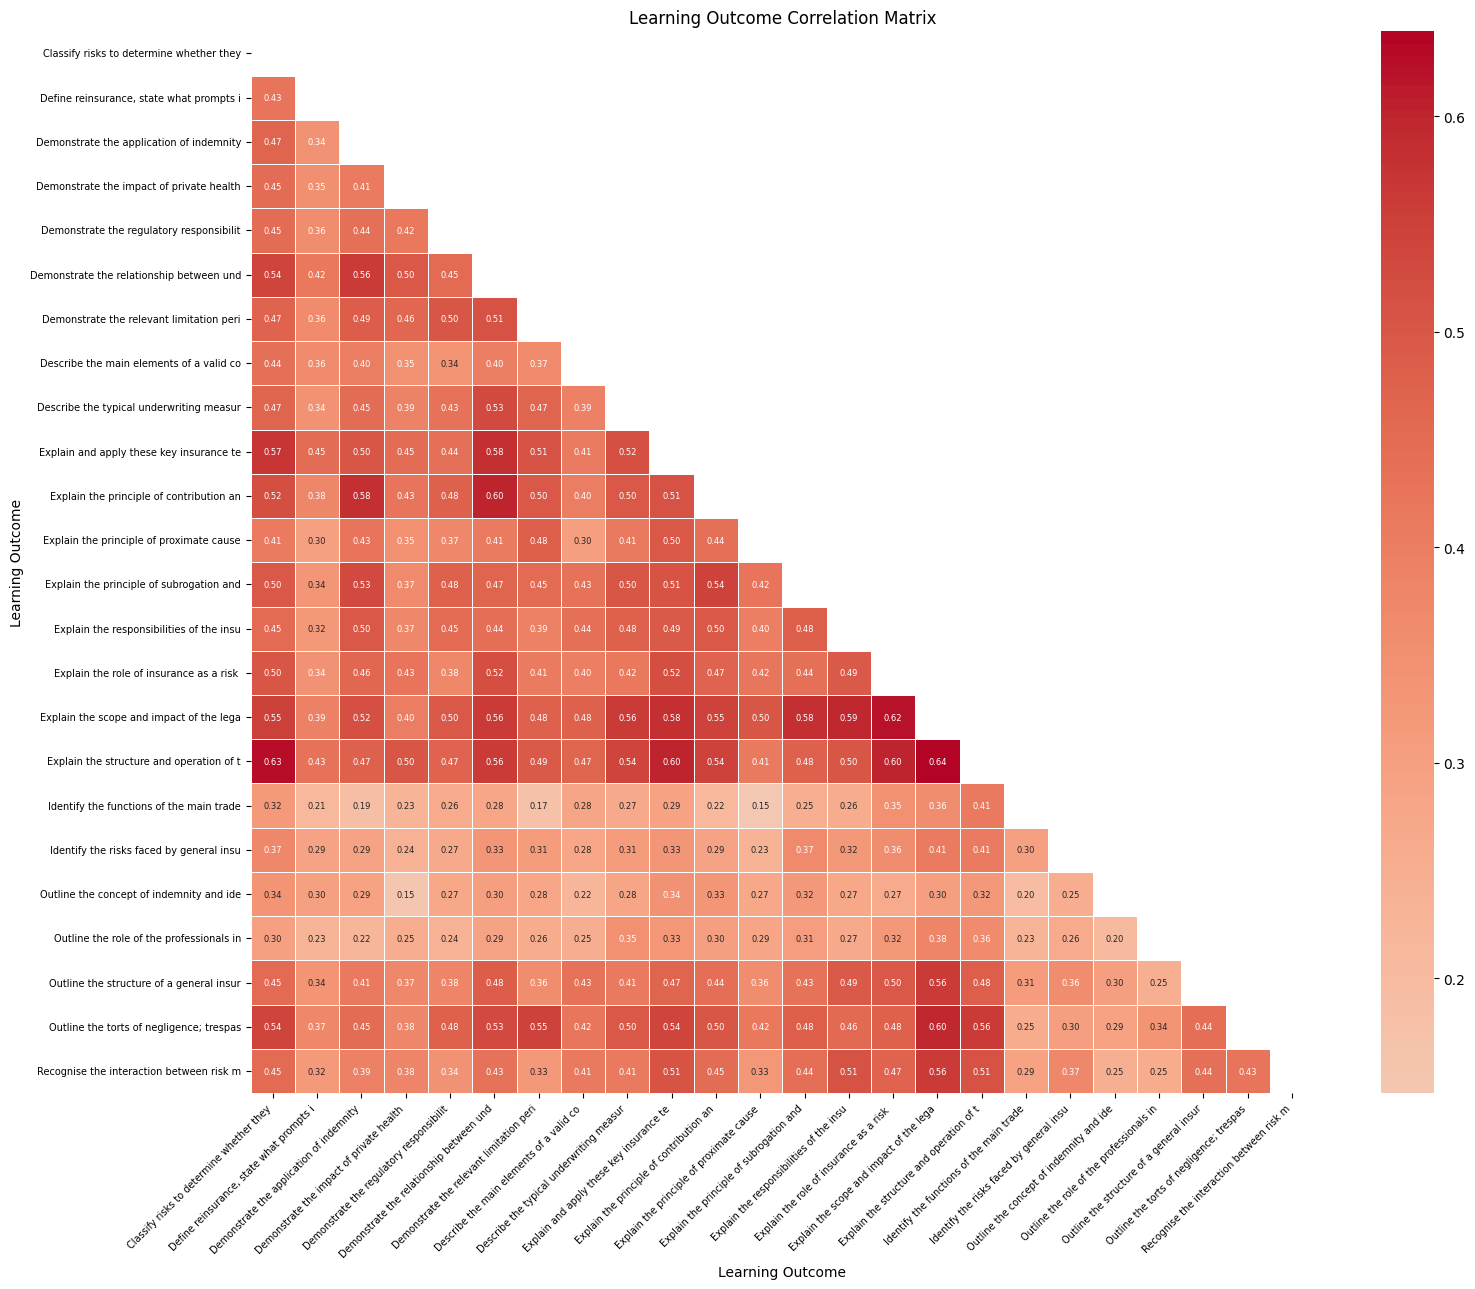


Highly correlated outcome pairs (|r| > 0.5): 52
                               Outcome A                                Outcome B  Correlation
Explain the scope and impact of the lega Explain the structure and operation of t        0.639
Classify risks to determine whether they Explain the structure and operation of t        0.625
Explain the role of insurance as a risk  Explain the scope and impact of the lega        0.623
Explain and apply these key insurance te Explain the structure and operation of t        0.602
Explain the role of insurance as a risk  Explain the structure and operation of t        0.600
Demonstrate the relationship between und Explain the principle of contribution an        0.599
Explain the scope and impact of the lega Outline the torts of negligence; trespas        0.595
Explain the responsibilities of the insu Explain the scope and impact of the lega        0.594
Explain the principle of subrogation and Explain the scope and impact of the lega        0.583
E

In [22]:
# 4.4 Learning outcome correlation matrix
# Pivot to candidate × outcome correct rate
outcome_pivot = merged_df.groupby(
    ["Student ID", "Learning Outcome"]
)["Correct"].mean().unstack()

outcome_pivot.columns = outcome_pivot.columns.str[:40]

corr_matrix = outcome_pivot.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 6}
)
ax.set_title("Learning Outcome Correlation Matrix")
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("eda2_outcome_correlation.png", dpi=150)
plt.show()

# This is to see if there are any strong clusters
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            high_corr.append({
                "Outcome A": corr_matrix.columns[i],
                "Outcome B": corr_matrix.columns[j],
                "Correlation": round(val, 3)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values("Correlation", ascending=False)
print(f"\nHighly correlated outcome pairs (|r| > 0.5): {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Distribution of weak outcomes per failing candidate:
count    151.0
mean      14.9
std        3.3
min        7.0
25%       13.0
50%       15.0
75%       17.0
max       23.0
Name: Weak Outcomes, dtype: float64

Value counts:
Weak Outcomes
7      1
9      4
10     8
11    11
12    11
13    13
14    25
15    17
16    18
17    10
18    12
19     6
20     4
21     5
22     4
23     2
Name: count, dtype: int64


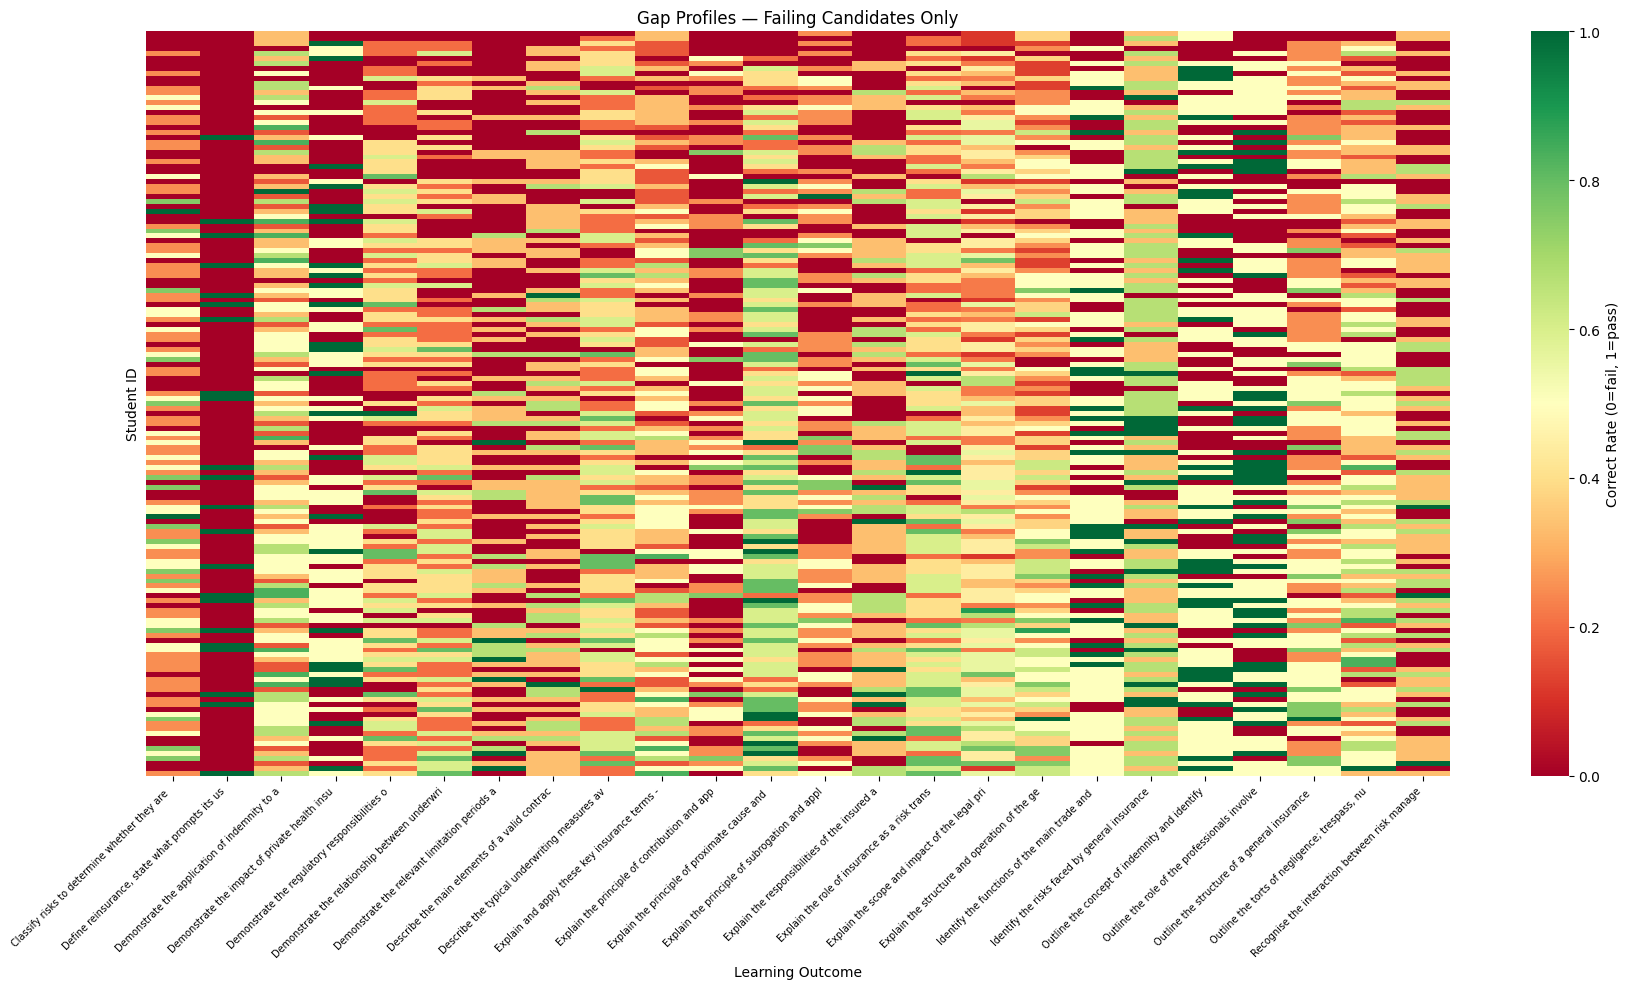

In [23]:
# 4.5 Gap profiles for failing candidates

# Per-candidate outcome correct rate (failing candidates only)
fail_ids = merged_df[merged_df["Overall Result"] == "Fail"]["Student ID"].unique()
fail_df = merged_df[merged_df["Student ID"].isin(fail_ids)]

fail_profiles = fail_df.groupby(
    ["Student ID", "Learning Outcome"]
)["Correct"].mean().unstack()

fail_profiles.columns = fail_profiles.columns.str[:45]

# Fix: explicitly select outcome columns only
outcome_cols = [c for c in fail_profiles.columns]
fail_profiles["Weak Outcomes"] = (fail_profiles[outcome_cols] < 0.5).sum(axis=1)

print("Distribution of weak outcomes per failing candidate:")
print(fail_profiles["Weak Outcomes"].describe().round(1))
print("\nValue counts:")
print(fail_profiles["Weak Outcomes"].value_counts().sort_index())

# Heatmap of failing candidate profiles
fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    fail_profiles.drop(columns="Weak Outcomes"),
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0,
    yticklabels=False,
    ax=ax,
    cbar_kws={"label": "Correct Rate (0=fail, 1=pass)"}
)
ax.set_title("Gap Profiles — Failing Candidates Only")
ax.set_xlabel("Learning Outcome")
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda2_fail_gap_profiles.png", dpi=150)
plt.show()

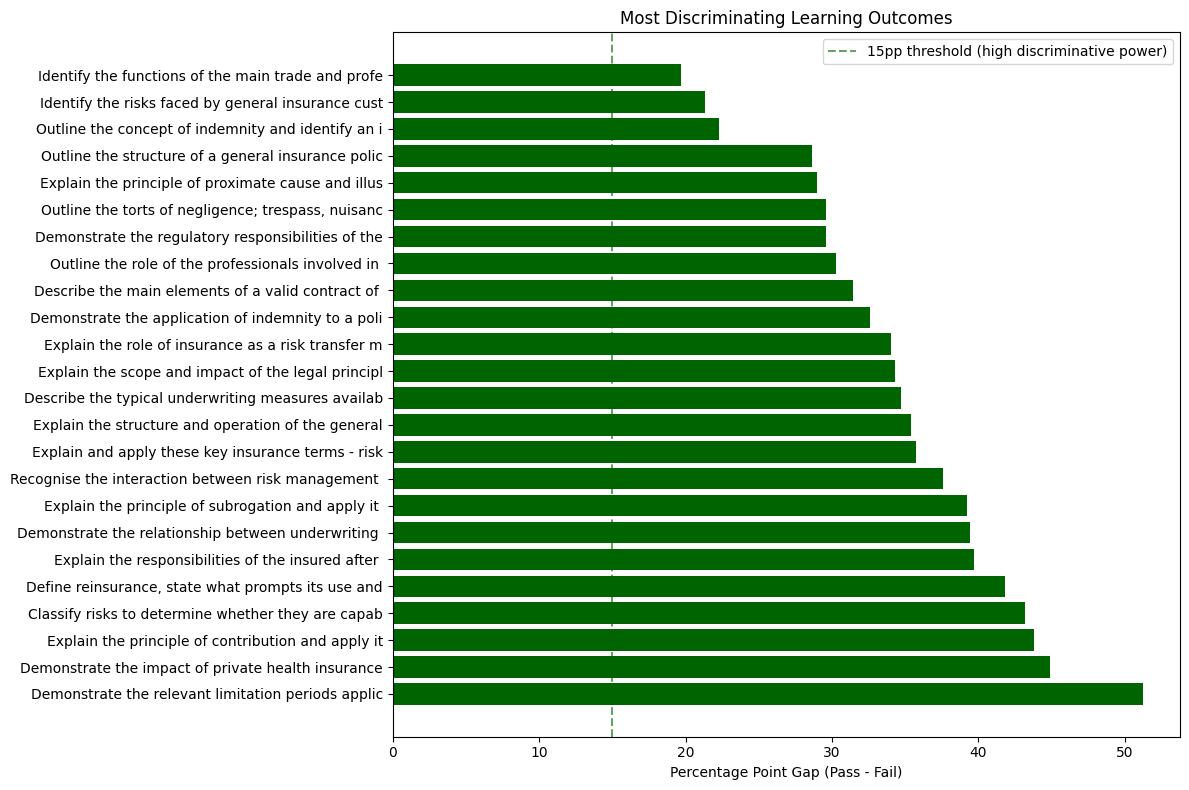

                                  Learning Outcome    Fail %    Pass %  Gap (pp)
Demonstrate the relevant limitation periods applic 20.529801 71.707317      51.2
Demonstrate the impact of private health insurance 34.105960 79.024390      44.9
Explain the principle of contribution and apply it 18.377483 62.134146      43.8
Classify risks to determine whether they are capab 27.483444 70.670732      43.2
Define reinsurance, state what prompts its use and 14.569536 56.341463      41.8
Explain the responsibilities of the insured after  30.242826 69.918699      39.7
Demonstrate the relationship between underwriting  29.668874 69.024390      39.4
Explain the principle of subrogation and apply it  25.165563 64.329268      39.2
Recognise the interaction between risk management  28.697572 66.260163      37.6
Explain and apply these key insurance terms - risk 33.554084 69.268293      35.7


In [24]:
# 4.6 Most discriminating outcomes (biggest pass/fail gap)

# Which outcomes best separate pass from fail?
discriminative = outcome_by_result.copy()
discriminative = discriminative.sort_values(
    "Gap (Pass - Fail)", ascending=False
).reset_index()
discriminative.columns = ["Learning Outcome", "Fail %", "Pass %", "Gap (pp)"]

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["darkgreen" if g >= 15 else "steelblue" for g in discriminative["Gap (pp)"]]
ax.barh(discriminative["Learning Outcome"], discriminative["Gap (pp)"], color=colors)
ax.axvline(x=15, color="darkgreen", linestyle="--",
           alpha=0.6, label="15pp threshold (high discriminative power)")
ax.set_xlabel("Percentage Point Gap (Pass - Fail)")
ax.set_title("Most Discriminating Learning Outcomes")
ax.legend()
plt.tight_layout()
plt.savefig("eda2_discriminative_outcomes.png", dpi=150)
plt.show()

print(discriminative.head(10).to_string(index=False))

Response breakdown by result
Response Type   Correct  Omitted  Wrong
Overall Result                         
Fail               36.1     31.7   32.2
Pass               70.6     16.8   12.5


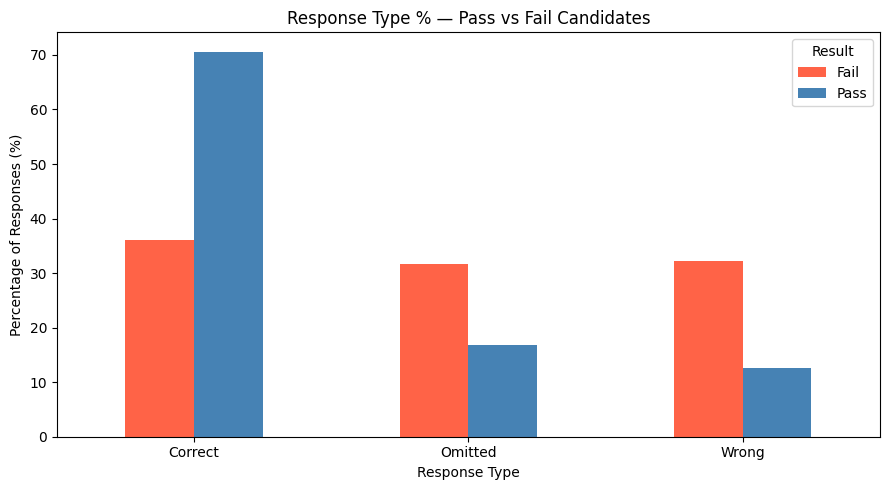

In [25]:
# 4.7 Wrong vs omitted by pass/fail (negative marking behaviour)

response_split = merged_df.groupby(
    ["Overall Result", "Response Type"]
).size().unstack(fill_value=0)

response_pct = response_split.div(response_split.sum(axis=1), axis=0) * 100

print("Response breakdown by result")
print(response_pct.round(1))

response_pct.T.plot(
    kind="bar",
    figsize=(9, 5),
    color=["tomato", "steelblue"],

)
plt.title("Response Type % — Pass vs Fail Candidates")
plt.ylabel("Percentage of Responses (%)")
plt.xlabel("Response Type")
plt.xticks(rotation=0)
plt.legend(title="Result")
plt.tight_layout()
plt.savefig("eda2_response_type_by_result.png", dpi=150)
plt.show()

In [26]:
# 4.8 Save full EDA summary
# Candidate-level summary for all 561
candidate_summary = merged_df.groupby("Student ID").agg(
    Overall_Score=("Overall Score", "first"),
    Overall_Result=("Overall Result", "first"),
    Correct_Rate=("Correct", "mean"),
    Omit_Rate=("Response Type", lambda x: (x == "Omitted").mean()),
    Wrong_Rate=("Response Type", lambda x: (x == "Wrong").mean())
).reset_index()

candidate_summary["Correct_%"] = (candidate_summary["Correct_Rate"] * 100).round(1)
candidate_summary["Omit_%"]    = (candidate_summary["Omit_Rate"]    * 100).round(1)
candidate_summary["Wrong_%"]   = (candidate_summary["Wrong_Rate"]   * 100).round(1)

candidate_summary.drop(
    columns=["Correct_Rate", "Omit_Rate", "Wrong_Rate"]
).to_csv("eda2_candidate_summary.csv", index=False)

outcome_by_result.to_csv("eda2_outcome_passrate_by_result.csv")
omit_rates.to_csv("eda2_omission_by_outcome.csv")

print("saved: candidate_summary, outcome_passrate, omission_by_outcome")
candidate_summary.head()

saved: candidate_summary, outcome_passrate, omission_by_outcome


,Student ID,Overall_Score,Overall_Result,Correct_Rate,Omit_Rate,Wrong_Rate,Correct_%,Omit_%,Wrong_%
0,1,-3,Fail,0.12,0.49,0.39,12.0,49.0,39.0
1,2,11,Fail,0.14,0.55,0.31,14.0,55.0,31.0
2,3,13,Fail,0.17,0.45,0.38,17.0,45.0,38.0
3,4,16,Fail,0.13,0.64,0.23,13.0,64.0,23.0
4,5,20,Fail,0.30,0.00,0.70,30.0,0.0,70.0


In [27]:
# 5.1 Candidate Matrix Load
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the wide-format candidate matrix
pivot_df = pd.read_csv("gapfinder_candidate_matrix.csv")

# Separate features, labels and metadata
X = pivot_df.drop(columns=["Student ID", "Overall Score", "Overall Result"])
y = pivot_df["Overall Result"]  # Pass/Fail — used for stratification
student_ids = pivot_df["Student ID"]

print(f"n = {X.shape[0]}, features = {X.shape[1]}")
print(y.value_counts())

n = 561, features = 100
Overall Result
Pass    410
Fail    151
Name: count, dtype: int64


In [28]:
#5.2 Stratify splits
# First split will be 70% train, 30% temp, which becomes 15% validation + 15% test
X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X, y, student_ids,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: split will be temp 50/50 into validation and test
X_val, X_test, y_val, y_test, id_val, id_test = train_test_split(
    X_temp, y_temp, id_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Train:      {X_train.shape[0]} candidates")
print(f"Validation: {X_val.shape[0]} candidates")
print(f"Test:       {X_test.shape[0]} candidates")
print(f"Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} candidates")

Train:      392 candidates
Validation: 84 candidates
Test:       85 candidates
Total:      561 candidates


In [29]:
# 5.3 Verify stratification
for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    pct = labels.value_counts(normalize=True).round(2)
    print(f"{name}: pass={pct['Pass']}, fail={pct['Fail']}")

train: pass=0.73, fail=0.27
val: pass=0.74, fail=0.26
test: pass=0.73, fail=0.27


In [30]:
# 5.4 Save splits
# Reassemble with IDs and labels for saving
def make_split_df(ids, X, y):
    df = X.copy()
    df.insert(0, "Student ID", ids.values)
    df["Overall Result"] = y.values
    return df

train_df = make_split_df(id_train, X_train, y_train)
val_df   = make_split_df(id_val,   X_val,   y_val)
test_df  = make_split_df(id_test,  X_test,  y_test)

train_df.to_csv("gapfinder_train.csv", index=False)
val_df.to_csv("gapfinder_val.csv",     index=False)
test_df.to_csv("gapfinder_test.csv",   index=False)

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

train=392, val=84, test=85


In [31]:
# 6.1 Split and Q-Matrix Load
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (hamming_loss, recall_score,
                             precision_score, f1_score, classification_report)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load splits
train_df = pd.read_csv("gapfinder_train.csv")
val_df   = pd.read_csv("gapfinder_val.csv")
test_df  = pd.read_csv("gapfinder_test.csv")

# Load Q-matrix
q_matrix = pd.read_csv("gapfinder_qmatrix.csv", index_col="Question Number")
q_matrix = q_matrix.drop(columns=["Chapter"])

# Question columns (1-100)
question_cols = [str(i) for i in range(1, 101)]

# Separate features
X_train = train_df[question_cols].values
X_val   = val_df[question_cols].values
X_test  = test_df[question_cols].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Q-matrix shape: {q_matrix.shape}")

Train: (392, 100), Val: (84, 100), Test: (85, 100)
Q-matrix shape: (100, 24)


In [32]:
#6.2 Mastery labels from Q-Matrix
def create_mastery_labels(X, q_matrix, threshold=0.5):
    """
    For each candidate and each learning outcome,
    compute proportion of outcome questions answered correctly.
    If >= threshold, label as mastered (1), else not mastered (0).
    """
    outcomes = q_matrix.columns.tolist()
    q_matrix_vals = q_matrix.values  # shape: 100 x 24

    mastery = np.zeros((X.shape[0], len(outcomes)))

    for i, outcome_idx in enumerate(range(len(outcomes))):
        # Get question indices for this outcome
        q_indices = np.where(q_matrix_vals[:, outcome_idx] == 1)[0]
        # Get responses for those questions
        outcome_responses = X[:, q_indices]
        # Compute proportion correct
        prop_correct = outcome_responses.mean(axis=1)
        # Apply threshold
        mastery[:, i] = (prop_correct >= threshold).astype(int)

    return mastery, outcomes

Y_train, outcomes = create_mastery_labels(X_train, q_matrix)
Y_val, _          = create_mastery_labels(X_val,   q_matrix)
Y_test, _         = create_mastery_labels(X_test,  q_matrix)

print(f"Mastery label matrix shape: {Y_train.shape}")
print(f"\nMastery rate per outcome (train) — sample:")
for i, o in enumerate(outcomes[:5]):
    print(f"  {o[:60]}: {Y_train[:, i].mean():.2f}")

Mastery label matrix shape: (392, 24)

Mastery rate per outcome (train) — sample:
  Classify risks to determine whether they are capable of bein: 0.69
  Define reinsurance, state what prompts its use and outline t: 0.41
  Demonstrate the application of indemnity to a policy of insu: 0.81
  Demonstrate the impact of private health insurance principle: 0.84
  Demonstrate the regulatory responsibilities of the insurer a: 0.55


In [33]:
# 6.3 Majority Class Baseline
def majority_class_baseline(Y_train, Y_test, outcomes):
    """
    For each outcome, predict the majority class from training set
    for every candidate in the test set.
    """
    # Find majority class per outcome from training data
    majority = (Y_train.mean(axis=0) >= 0.5).astype(int)

    # Predict same majority class for all test candidates
    Y_pred = np.tile(majority, (Y_test.shape[0], 1))

    # Compute metrics
    hl = hamming_loss(Y_test, Y_pred)
    recall    = recall_score(Y_test, Y_pred, average="macro", zero_division=0)
    precision = precision_score(Y_test, Y_pred, average="macro", zero_division=0)
    f1        = f1_score(Y_test, Y_pred, average="macro", zero_division=0)


    print(f"Hamming Loss: {hl:.4f}")
    print(f"Macro Recall: {recall:.4f}")
    print(f"Macro Precision {precision:.4f}")
    print(f"Macro F1: {f1:.4f}")

    print("\nPer-outcome Recall:")
    per_outcome_recall = recall_score(Y_test, Y_pred, average=None, zero_division=0)
    for o, r in zip(outcomes, per_outcome_recall):
        print(f"  {o[:60]:60s}  Recall: {r:.2f}")

    return Y_pred, majority

Y_pred_majority, majority_classes = majority_class_baseline(
    Y_train, Y_test, outcomes
)

Hamming Loss: 0.2828
Macro Recall: 0.9167
Macro Precision 0.6789
Macro F1: 0.7761

Per-outcome Recall:
  Classify risks to determine whether they are capable of bein  Recall: 1.00
  Define reinsurance, state what prompts its use and outline t  Recall: 0.00
  Demonstrate the application of indemnity to a policy of insu  Recall: 1.00
  Demonstrate the impact of private health insurance principle  Recall: 1.00
  Demonstrate the regulatory responsibilities of the insurer a  Recall: 1.00
  Demonstrate the relationship between underwriting and the pr  Recall: 1.00
  Demonstrate the relevant limitation periods applicable in to  Recall: 1.00
  Describe the main elements of a valid contract of insurance,  Recall: 0.00
  Describe the typical underwriting measures available to an u  Recall: 1.00
  Explain and apply these key insurance terms - risk, uncertai  Recall: 1.00
  Explain the principle of contribution and apply it in situat  Recall: 1.00
  Explain the principle of proximate cause and ill

In [34]:
# 6.4 Logisitic regression baseline
def logistic_regression_baseline(X_train, Y_train, X_test, Y_test, outcomes):
    """
    Train a separate logistic regression per learning outcome.
    Predict mastery on the test set and evaluate.
    """
    Y_pred = np.zeros_like(Y_test)
    models = []

    for i, outcome in enumerate(outcomes):
        lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        lr.fit(X_train, Y_train[:, i])
        Y_pred[:, i] = lr.predict(X_test)
        models.append(lr)

    # Compute metrics
    hl        = hamming_loss(Y_test, Y_pred)
    recall    = recall_score(Y_test, Y_pred, average="macro", zero_division=0)
    precision = precision_score(Y_test, Y_pred, average="macro", zero_division=0)
    f1        = f1_score(Y_test, Y_pred, average="macro", zero_division=0)


    print(f"Hamming Loss: {hl:.4f}")
    print(f"Macro Recall:  {recall:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro F1: {f1:.4f}")

    print("\nPer-outcome Recall:")
    per_outcome_recall = recall_score(Y_test, Y_pred, average=None, zero_division=0)
    for o, r in zip(outcomes, per_outcome_recall):
        flag = " ⚠️" if r < 0.80 else ""
        print(f"  {o[:60]:60s}  Recall: {r:.2f}{flag}")

    return Y_pred, models, per_outcome_recall

Y_pred_lr, lr_models, lr_per_outcome = logistic_regression_baseline(
    X_train, Y_train, X_test, Y_test, outcomes
)

Hamming Loss: 0.0402
Macro Recall:  0.9808
Macro Precision: 0.9653
Macro F1: 0.9728

Per-outcome Recall:
  Classify risks to determine whether they are capable of bein  Recall: 0.95
  Define reinsurance, state what prompts its use and outline t  Recall: 1.00
  Demonstrate the application of indemnity to a policy of insu  Recall: 0.94
  Demonstrate the impact of private health insurance principle  Recall: 1.00
  Demonstrate the regulatory responsibilities of the insurer a  Recall: 0.96
  Demonstrate the relationship between underwriting and the pr  Recall: 0.96
  Demonstrate the relevant limitation periods applicable in to  Recall: 0.96
  Describe the main elements of a valid contract of insurance,  Recall: 0.98
  Describe the typical underwriting measures available to an u  Recall: 1.00
  Explain and apply these key insurance terms - risk, uncertai  Recall: 1.00
  Explain the principle of contribution and apply it in situat  Recall: 0.96
  Explain the principle of proximate cause and i

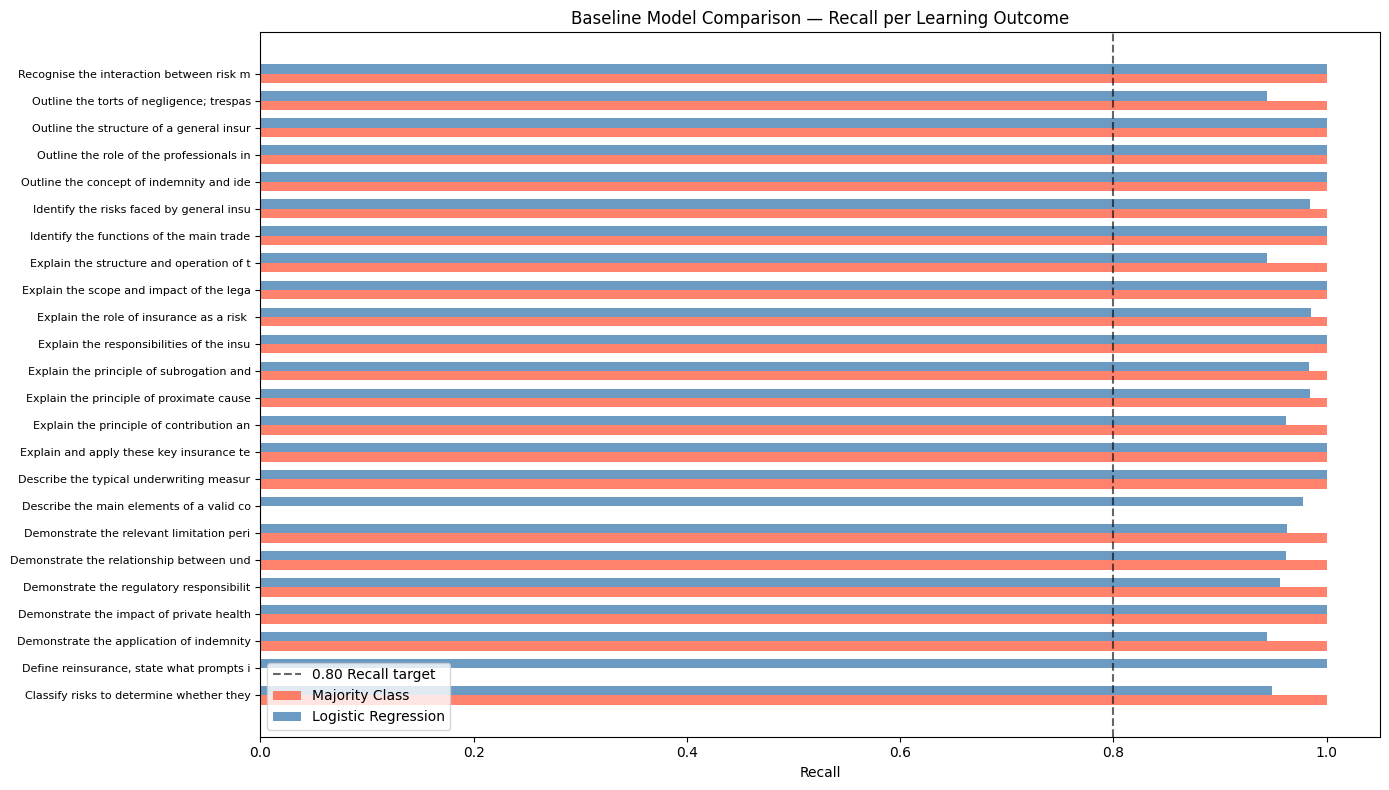

In [35]:
# 6.5 Comparison Chart
# This is used to compare the majority class vs logistic regression per outcome
majority_recall = recall_score(Y_test, Y_pred_majority, average=None, zero_division=0)

short_labels = [o[:40] for o in outcomes]
x = np.arange(len(outcomes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(x - width/2, majority_recall, width, label="Majority Class", color="tomato", alpha=0.8)
ax.barh(x + width/2, lr_per_outcome,  width, label="Logistic Regression", color="steelblue", alpha=0.8)
ax.axvline(x=0.80, color="black", linestyle="--", alpha=0.6, label="0.80 Recall target")
ax.set_yticks(x)
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel("Recall")
ax.set_title("Baseline Model Comparison — Recall per Learning Outcome")
ax.legend()
plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150)
plt.show()

In [36]:
# 6.6 Summary table
majority_recall_per = recall_score(Y_test, Y_pred_majority, average=None, zero_division=0)

summary = pd.DataFrame({
    "Learning Outcome": [o[:70] for o in outcomes],
    "Majority Recall": majority_recall_per.round(3),
    "LR Recall": lr_per_outcome.round(3),
    "LR beats target": lr_per_outcome >= 0.80
})

summary = summary.sort_values("LR Recall", ascending=False)
summary.to_csv("baseline_results.csv", index=False)

print("Summary:")
print(f"Outcomes where LR meets 0.80 Recall target: "
      f"{summary['LR beats target'].sum()} / {len(outcomes)}")
print("\nFull table:")
print(summary.to_string(index=False))

Summary:
Outcomes where LR meets 0.80 Recall target: 24 / 24

Full table:
                                                      Learning Outcome  Majority Recall  LR Recall  LR beats target
Define reinsurance, state what prompts its use and outline the main ty              0.0      1.000             True
Demonstrate the impact of private health insurance principles on the u              1.0      1.000             True
Outline the structure of a general insurance policy and explain the im              1.0      1.000             True
Outline the role of the professionals involved in the general insuranc              1.0      1.000             True
             Explain the responsibilities of the insured after a loss.              1.0      1.000             True
Explain the scope and impact of the legal principles of insurable inte              1.0      1.000             True
Explain and apply these key insurance terms - risk, uncertainty, frequ              1.0      1.000             Tru

In [37]:
# 7.1 SHAP Installment for later use
!pip install shap --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss, recall_score, precision_score, f1_score
import shap
import warnings
warnings.filterwarnings("ignore")

# Use GPU if available in Colab, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [38]:
# 7.2 Load data/Q-Matrix
# Load the train, validation and test splits produced earlier
train_df = pd.read_csv("gapfinder_train.csv")
val_df   = pd.read_csv("gapfinder_val.csv")
test_df  = pd.read_csv("gapfinder_test.csv")

# Load the Q-matrix — this is the structural constraint for the network
q_matrix = pd.read_csv("gapfinder_qmatrix.csv", index_col="Question Number")
q_matrix = q_matrix.drop(columns=["Chapter"])

# Store outcome names for reporting later
outcome_names = q_matrix.columns.tolist()
n_questions = 100
n_outcomes  = len(outcome_names)  # 24

print(f"Questions: {n_questions}, Learning Outcomes: {n_outcomes}")
print(f"Outcomes: {outcome_names[:3]} ...")

Questions: 100, Learning Outcomes: 24
Outcomes: ['Classify risks to determine whether they are capable of being insured.', 'Define reinsurance, state what prompts its use and outline the main types of reinsurance.', 'Demonstrate the application of indemnity to a policy of insurance.'] ...


In [39]:
# 7.3 Prepares features/mastery labels

question_cols = [str(i) for i in range(1, 101)]

def create_mastery_labels(X, q_matrix, threshold=0.5):
    """
    Derives binary mastery labels from item responses and the Q-matrix.
    For each candidate and outcome, if they answered >= 50% of the
    outcome's questions correctly they are considered to have mastered it.
    """
    outcomes = q_matrix.columns.tolist()
    q_vals   = q_matrix.values
    mastery  = np.zeros((X.shape[0], len(outcomes)))

    for i in range(len(outcomes)):
        # Find which questions assess this outcome
        q_indices = np.where(q_vals[:, i] == 1)[0]
        # Compute proportion correct for those questions only
        prop_correct = X[:, q_indices].mean(axis=1)
        mastery[:, i] = (prop_correct >= threshold).astype(int)

    return mastery, outcomes

# Extract feature matrices
X_train_np = train_df[question_cols].values.astype(np.float32)
X_val_np   = val_df[question_cols].values.astype(np.float32)
X_test_np  = test_df[question_cols].values.astype(np.float32)

# Derive mastery labels
Y_train_np, outcomes = create_mastery_labels(X_train_np, q_matrix)
Y_val_np, _          = create_mastery_labels(X_val_np,   q_matrix)
Y_test_np, _         = create_mastery_labels(X_test_np,  q_matrix)

Y_train_np = Y_train_np.astype(np.float32)
Y_val_np   = Y_val_np.astype(np.float32)
Y_test_np  = Y_test_np.astype(np.float32)

print(f"Training features:  {X_train_np.shape}")
print(f"Training labels:    {Y_train_np.shape}")

Training features:  (392, 100)
Training labels:    (392, 24)


In [40]:
# 7.4 Builds Pytech and Data Loaders

# Convert numpy arrays to PyTorch tensors and move to device
def to_tensor(X, Y):
    return (
        torch.tensor(X).to(device),
        torch.tensor(Y).to(device)
    )

X_train_t, Y_train_t = to_tensor(X_train_np, Y_train_np)
X_val_t,   Y_val_t   = to_tensor(X_val_np,   Y_val_np)
X_test_t,  Y_test_t  = to_tensor(X_test_np,  Y_test_np)

# DataLoader batches the training data for efficient mini-batch gradient descent
train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training batches per epoch: {len(train_loader)}")

Training batches per epoch: 13


In [41]:
# 7.5 Defines the QNN Architecture

class QNN(nn.Module):
    """
    Q-Matrix Constrained Neural Network for knowledge gap diagnosis.

    The network takes a candidate's binary item response vector (100 questions)
    and produces a mastery probability for each of the 24 learning outcomes.

    The key innovation is the Q-matrix mask applied to the output layer:
    each outcome neuron only receives signal from questions that assess it,
    enforcing the syllabus structure as a hard constraint on the network.
    """

    def __init__(self, n_questions, n_outcomes, q_matrix_tensor,
                 hidden_dim=64, dropout_rate=0.3):
        super(QNN, self).__init__()

        # Store the Q-matrix as a fixed non-trainable mask
        # This is the core constraint — shape: (n_questions, n_outcomes)
        self.register_buffer("q_mask", q_matrix_tensor)

        # Shared hidden layers learn general response patterns
        # across all candidates before outcome-specific diagnosis
        self.hidden = nn.Sequential(
            nn.Linear(n_questions, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),      # Dropout reduces overfitting
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Output layer: one neuron per learning outcome
        # The Q-matrix mask is applied to the weights here
        self.output_layer = nn.Linear(hidden_dim, n_outcomes)

        # Sigmoid squashes output to [0,1] — interpretable as mastery probability
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward pass: input responses → hidden representation → masked output.
        """
        # Pass responses through shared hidden layers
        hidden = self.hidden(x)

        # Raw output — one value per outcome
        raw_output = self.output_layer(hidden)

        # Apply sigmoid to get mastery probabilities
        mastery_probs = self.sigmoid(raw_output)

        return mastery_probs

In [42]:
# 7.6 Initialises the Model

# Convert Q-matrix to a PyTorch tensor for use as the network mask
q_matrix_tensor = torch.tensor(
    q_matrix.values.T.astype(np.float32)
).to(device)  # Shape: (n_outcomes, n_questions)

# Initialise the QNN
model = QNN(
    n_questions    = n_questions,
    n_outcomes     = n_outcomes,
    q_matrix_tensor = q_matrix_tensor,
    hidden_dim     = 64,
    dropout_rate   = 0.3
).to(device)

# Binary cross-entropy loss — appropriate for multi-label binary classification
# Each outcome is treated as an independent binary prediction
criterion = nn.BCELoss()

# Adam optimiser — adaptive learning rate, well suited to small datasets
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)
print(f"\nTotal trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

QNN(
  (hidden): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=64, out_features=24, bias=True)
  (sigmoid): Sigmoid()
)

Total trainable parameters: 12,184


In [43]:
# 7.7 Training loop

def evaluate(model, X, Y):
    """
    Evaluates the model on a given set.
    Returns loss, Hamming Loss, and macro Recall.
    """
    model.eval()
    with torch.no_grad():
        preds_prob = model(X)
        loss = criterion(preds_prob, Y).item()
        preds_binary = (preds_prob.cpu().numpy() >= 0.5).astype(int)
        Y_np = Y.cpu().numpy()
        hl  = hamming_loss(Y_np, preds_binary)
        rec = recall_score(Y_np, preds_binary, average="macro", zero_division=0)
    return loss, hl, rec

# Training configuration
n_epochs    = 150
best_val_hl = float("inf")
best_epoch  = 0
patience    = 20   # Stop early if no improvement after 20 epochs
no_improve  = 0

# Store history for plotting
history = {"train_loss": [], "val_loss": [],
           "train_hl": [],   "val_hl": [],
           "train_rec": [],  "val_rec": []}

print("Starting training...\n")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()           # Clear gradients from previous step
        preds = model(X_batch)          # Forward pass
        loss  = criterion(preds, Y_batch)  # Compute loss
        loss.backward()                 # Backpropagate
        optimizer.step()                # Update weights
        epoch_loss += loss.item()

    # Evaluate on train and validation sets
    train_loss, train_hl, train_rec = evaluate(model, X_train_t, Y_train_t)
    val_loss,   val_hl,   val_rec   = evaluate(model, X_val_t,   Y_val_t)

    # Store metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_hl"].append(train_hl)
    history["val_hl"].append(val_hl)
    history["train_rec"].append(train_rec)
    history["val_rec"].append(val_rec)

    # Save best model based on validation Hamming Loss
    if val_hl < best_val_hl:
        best_val_hl = val_hl
        best_epoch  = epoch
        torch.save(model.state_dict(), "gapfinder_qnn_best.pt")
        no_improve  = 0
    else:
        no_improve += 1

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val HL: {val_hl:.4f} | Val Recall: {val_rec:.4f}")

    # Early stopping
    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no improvement for {patience} epochs)")
        break

print(f"\nBest model saved at epoch {best_epoch+1} "
      f"with validation Hamming Loss: {best_val_hl:.4f}")

Starting training...

Epoch  10 | Train Loss: 0.4320 | Val Loss: 0.4145 | Val HL: 0.1935 | Val Recall: 0.9365
Epoch  20 | Train Loss: 0.3974 | Val Loss: 0.3956 | Val HL: 0.1811 | Val Recall: 0.9352
Epoch  30 | Train Loss: 0.3592 | Val Loss: 0.3724 | Val HL: 0.1622 | Val Recall: 0.9385
Epoch  40 | Train Loss: 0.3255 | Val Loss: 0.3510 | Val HL: 0.1538 | Val Recall: 0.9371
Epoch  50 | Train Loss: 0.2976 | Val Loss: 0.3339 | Val HL: 0.1508 | Val Recall: 0.9425
Epoch  60 | Train Loss: 0.2715 | Val Loss: 0.3209 | Val HL: 0.1394 | Val Recall: 0.9358
Epoch  70 | Train Loss: 0.2504 | Val Loss: 0.3042 | Val HL: 0.1290 | Val Recall: 0.9417
Epoch  80 | Train Loss: 0.2343 | Val Loss: 0.3007 | Val HL: 0.1314 | Val Recall: 0.9478
Epoch  90 | Train Loss: 0.2168 | Val Loss: 0.2887 | Val HL: 0.1245 | Val Recall: 0.9463
Epoch 100 | Train Loss: 0.2067 | Val Loss: 0.2851 | Val HL: 0.1205 | Val Recall: 0.9468
Epoch 110 | Train Loss: 0.1965 | Val Loss: 0.2831 | Val HL: 0.1195 | Val Recall: 0.9569
Epoch 120 

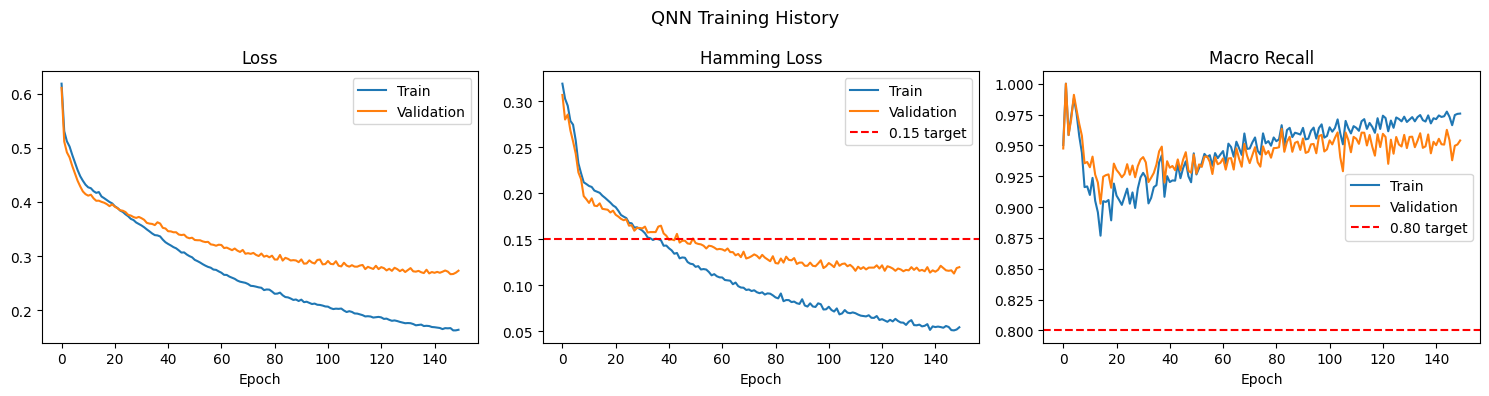

In [44]:
# 7.8 Plots training curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_hl"], label="Train")
axes[1].plot(history["val_hl"],   label="Validation")
axes[1].axhline(y=0.15, color="red", linestyle="--", label="0.15 target")
axes[1].set_title("Hamming Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["train_rec"], label="Train")
axes[2].plot(history["val_rec"],   label="Validation")
axes[2].axhline(y=0.80, color="red", linestyle="--", label="0.80 target")
axes[2].set_title("Macro Recall")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("QNN Training History", fontsize=13)
plt.tight_layout()
plt.savefig("qnn_training_curves.png", dpi=150)
plt.show()

In [45]:
# 7.9 Final dataset evaluation

# Load the best saved model
model.load_state_dict(torch.load("gapfinder_qnn_best.pt"))
model.eval()

with torch.no_grad():
    test_probs  = model(X_test_t).cpu().numpy()
    test_preds  = (test_probs >= 0.5).astype(int)

Y_test_np_eval = Y_test_t.cpu().numpy()

# Overall metrics
hl  = hamming_loss(Y_test_np_eval, test_preds)
rec = recall_score(Y_test_np_eval, test_preds, average="macro", zero_division=0)
pre = precision_score(Y_test_np_eval, test_preds, average="macro", zero_division=0)
f1  = f1_score(Y_test_np_eval, test_preds, average="macro", zero_division=0)

print("=== QNN RESULTS (Test Set) ===")
print(f"Hamming Loss:    {hl:.4f}  (target: < 0.15,  LR baseline: 0.0402)")
print(f"Macro Recall:    {rec:.4f}  (target: > 0.80,  LR baseline: 0.9808)")
print(f"Macro Precision: {pre:.4f}")
print(f"Macro F1:        {f1:.4f}")

# Per-outcome Recall
print("\nPer-outcome Recall:")
per_rec = recall_score(Y_test_np_eval, test_preds, average=None, zero_division=0)
for name, r in zip(outcome_names, per_rec):
    flag = " ⚠️" if r < 0.80 else ""
    print(f"  {name[:65]:65s}  {r:.2f}{flag}")

=== QNN RESULTS (Test Set) ===
Hamming Loss:    0.1270  (target: < 0.15,  LR baseline: 0.0402)
Macro Recall:    0.9330  (target: > 0.80,  LR baseline: 0.9808)
Macro Precision: 0.8966
Macro F1:        0.9134

Per-outcome Recall:
  Classify risks to determine whether they are capable of being ins  0.90
  Define reinsurance, state what prompts its use and outline the ma  1.00
  Demonstrate the application of indemnity to a policy of insurance  0.93
  Demonstrate the impact of private health insurance principles on   0.97
  Demonstrate the regulatory responsibilities of the insurer and th  0.91
  Demonstrate the relationship between underwriting and the premium  0.98
  Demonstrate the relevant limitation periods applicable in tort.    0.87
  Describe the main elements of a valid contract of insurance, how   0.82
  Describe the typical underwriting measures available to an underw  0.94
  Explain and apply these key insurance terms - risk, uncertainty,   0.95
  Explain the principle of contr